# L9_S：高細節 Mesh 重建

本 notebook 以車體 LiDAR 點雲 (`car6.pcd`) 為例，展示 Ball Pivoting 與 Poisson Surface Reconstruction 兩種方法，產生沒有破洞、面朝向一致、細節完整的三角網格。補洞區域會以醒目顏色標記，方便和原始表面區分，每一步都會開啟 Open3D 視窗並等待使用者手動關閉。

## 流程概覽
1. 載入並檢查車體點雲資料。
2. 以大半徑/大量鄰居參數估計法向量並統一方向，避免破面。
3. 使用 Ball Pivoting 產生稠密 mesh，並做拓樸清理與法向量重算。
4. 使用 Poisson Reconstruction (depth 11, scale 1.25) 取得具細節的封閉曲面，再以密度閾值與包圍盒裁切消除雜訊。
5. 兩種 mesh 都輸出到 `output_meshes/`，並自動將「原始支撐面」與「補洞面」上色。

In [2]:

import open3d as o3d
import numpy as np
from pathlib import Path

def show_geometries(geoms, window_name="Open3D Reconstruction Preview", width=1600, height=1000):
    """Utility viewer that blocks until the user closes the window."""
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name=window_name, width=width, height=height, visible=True)
    for geom in geoms:
        vis.add_geometry(geom)
    vis.run()
    vis.destroy_window()

def compute_vertex_support_distances(mesh: o3d.geometry.TriangleMesh, tree: o3d.geometry.KDTreeFlann) -> np.ndarray:
    """Return per-vertex distance to the nearest raw point for fill detection."""
    verts = np.asarray(mesh.vertices)
    distances = np.empty(len(verts), dtype=np.float64)
    for i, v in enumerate(verts):
        k, _, d2 = tree.search_knn_vector_3d(v, 1)
        distances[i] = np.sqrt(d2[0]) if k > 0 else np.inf
    return distances

def apply_fill_coloring(mesh, distances, base_color, fill_color, quantile):
    finite = distances[np.isfinite(distances)]
    if len(finite) == 0:
        threshold = np.inf
        mask = np.zeros_like(distances, dtype=bool)
    else:
        threshold = float(np.quantile(finite, quantile))
        mask = distances >= threshold
    colors = np.tile(base_color, (distances.shape[0], 1))
    colors[mask] = fill_color
    mesh.vertex_colors = o3d.utility.Vector3dVector(colors)
    return threshold, int(mask.sum())

POINT_CLOUD_PATH = Path("car6.pcd")
OUTPUT_DIR = Path("output_meshes")
OUTPUT_DIR.mkdir(exist_ok=True)
MESH_PREFIX = POINT_CLOUD_PATH.stem
FILL_QUANTILE = 0.9  # top 10% vertices farthest from original points are highlighted as fill
BASE_SURFACE_COLOR = np.array([0.78, 0.8, 0.86])
FILL_PATCH_COLOR = np.array([1.0, 0.38, 0.25])

print(f"Point cloud source: {POINT_CLOUD_PATH.resolve()}")
print(f"Meshes will be written under: {OUTPUT_DIR.resolve()}")


Point cloud source: /Users/hjc/venv/CV_Class/L9_S/car6.pcd
Meshes will be written under: /Users/hjc/venv/CV_Class/L9_S/output_meshes


In [3]:

pcd = o3d.io.read_point_cloud(str(POINT_CLOUD_PATH))
if len(pcd.points) == 0:
    raise ValueError(f"Failed to load any points from {POINT_CLOUD_PATH}")

pcd.paint_uniform_color([0.2, 0.6, 1.0])
min_bound = pcd.get_min_bound()
max_bound = pcd.get_max_bound()
diag = np.linalg.norm(max_bound - min_bound)
print(pcd)
print(f"Bounds min={min_bound}, max={max_bound}")
print(f"Diagonal length = {diag:.6f}")

pcd_tree = o3d.geometry.KDTreeFlann(pcd)

show_geometries([pcd], window_name="Step 1: Raw Point Cloud", width=1280, height=900)


PointCloud with 10031 points.
Bounds min=[-40.16899872 -68.55999756  -6.98999977], max=[-33.95000076 -61.88000107  -5.42999983]
Diagonal length = 9.259152


## 點雲法向量預處理
使用較大的鄰域半徑與 90 個鄰居估計法向量，搭配一致化避免破面。

In [4]:

min_bound = pcd.get_min_bound()
max_bound = pcd.get_max_bound()
bounding_box_diagonal = np.linalg.norm(max_bound - min_bound)
normal_radius = bounding_box_diagonal * 0.04  # 大半徑帶來更穩定、方向一致的法向量

pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=90))
pcd.orient_normals_consistent_tangent_plane(200)
pcd.orient_normals_to_align_with_direction(np.array([0.0, 0.0, 1.0]))
pcd.normalize_normals()

nn_dists = np.asarray(pcd.compute_nearest_neighbor_distance())
avg_nn = float(nn_dists.mean())
median_nn = float(np.median(nn_dists))
print(f"Average NN distance: {avg_nn:.6f}")
print(f"Median NN distance: {median_nn:.6f}")
print(f"Normal radius used: {normal_radius:.6f}")

show_geometries([pcd], window_name="Step 2: Normalized Point Cloud", width=1280, height=900)


Average NN distance: 0.052996
Median NN distance: 0.045619
Normal radius used: 0.370366


## Ball Pivoting 重建 (BPA)
以多組半徑掃描點雲，並在重建後移除退化/重複元素，確保 mesh 封閉且法向量正確，同時以距離門檻標示補洞區域。

In [7]:

radii = o3d.utility.DoubleVector([
    avg_nn * 3.0,
    avg_nn * 4.5,
    avg_nn * 6.0,
])
print("Ball Pivoting radii:", list(radii))

bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, radii)
bpa_mesh.remove_duplicated_vertices()
bpa_mesh.remove_duplicated_triangles()
bpa_mesh.remove_degenerate_triangles()
bpa_mesh.remove_non_manifold_edges()
bpa_mesh.orient_triangles()
bpa_mesh.compute_vertex_normals()

bpa_support_dist = compute_vertex_support_distances(bpa_mesh, pcd_tree)
bpa_threshold, bpa_fill_vertices = apply_fill_coloring(
    bpa_mesh,
    bpa_support_dist,
    base_color=BASE_SURFACE_COLOR,
    fill_color=FILL_PATCH_COLOR,
    quantile=FILL_QUANTILE,
)
print(f"BPA fill-distance threshold: {bpa_threshold:.4f}, highlighted vertices: {bpa_fill_vertices}")

bpa_mesh_path = OUTPUT_DIR / f"{MESH_PREFIX}_bpa_dense.ply"
o3d.io.write_triangle_mesh(str(bpa_mesh_path), bpa_mesh, write_ascii=False)
print(f"BPA mesh written to {bpa_mesh_path}")

show_geometries([bpa_mesh], window_name="Ball Pivoting Mesh (Color Separated)", width=1280, height=900)


Ball Pivoting radii: [0.1589878364170233, 0.23848175462553495, 0.3179756728340466]
BPA fill-distance threshold: 0.0000, highlighted vertices: 10025
BPA mesh written to output_meshes/car6_bpa_dense.ply


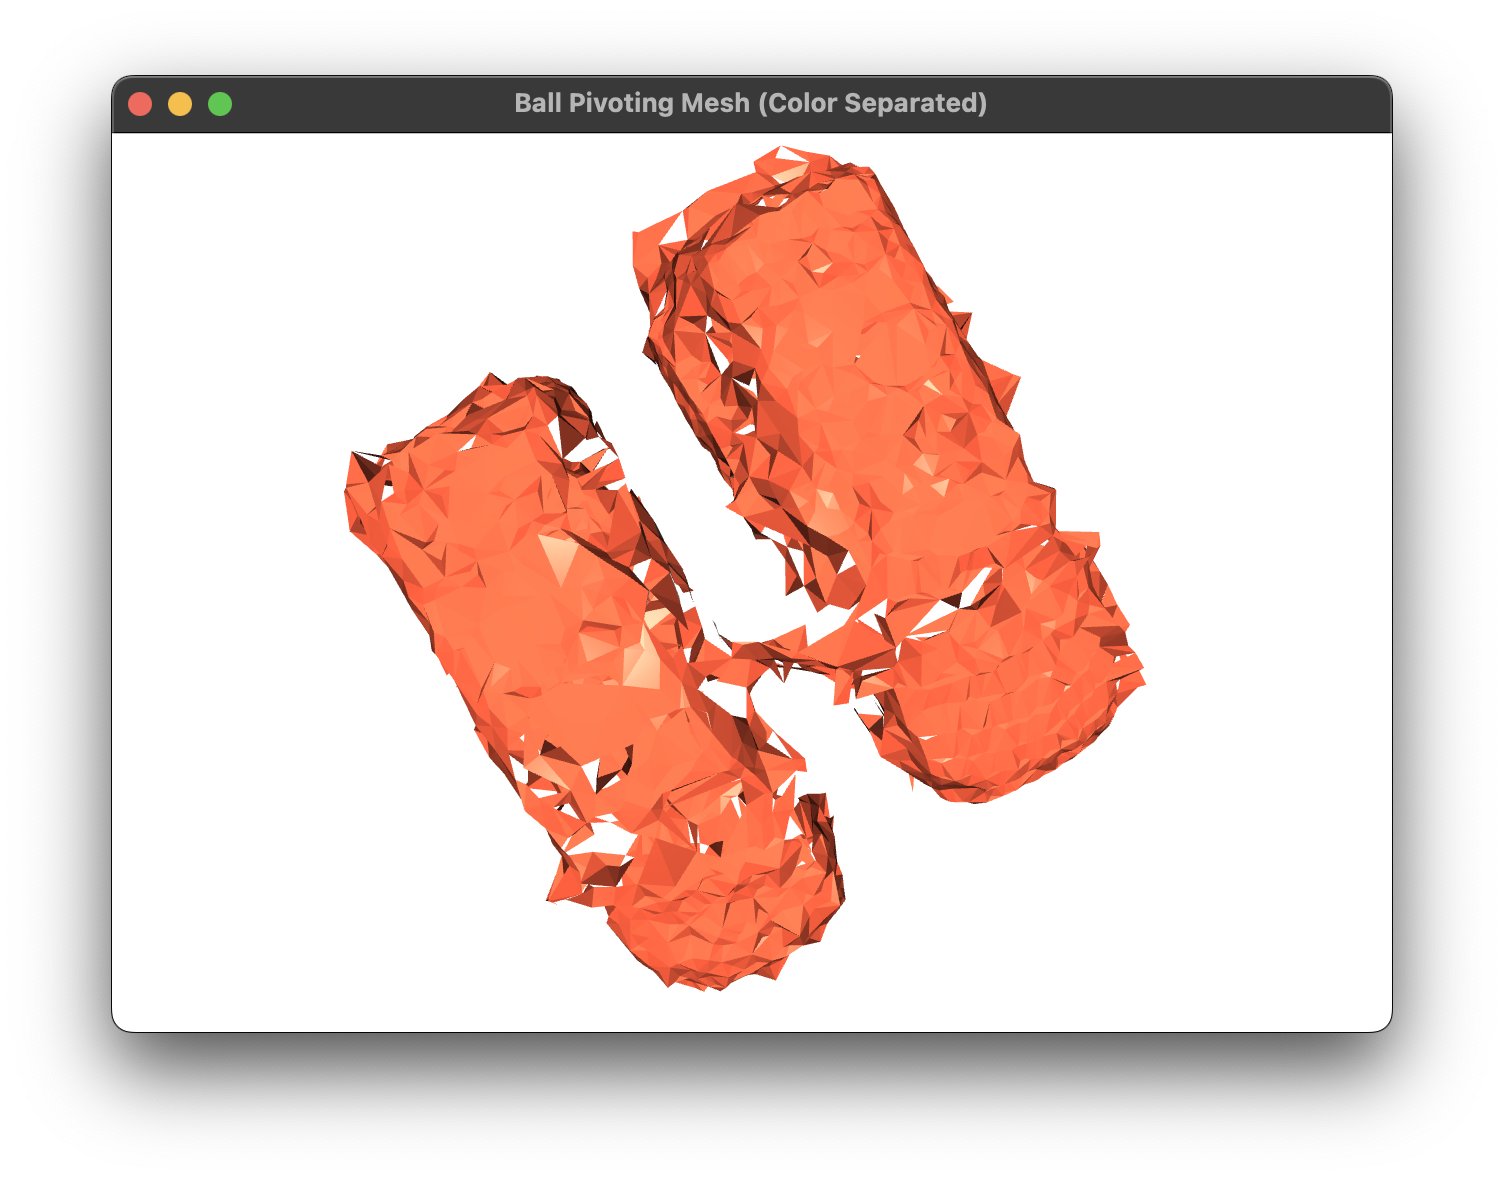

## Poisson Surface 重建
使用 depth=11、scale=1.25 等較大參數增加細節，並以最近距離門檻標示補洞區域。

In [6]:

poisson_mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd,
    depth=11,
    width=0,
    scale=1.25,
    linear_fit=False,
)
densities = np.asarray(densities)
density_threshold = np.quantile(densities, 0.02)
keep_mask = densities >= density_threshold
poisson_mesh.remove_vertices_by_mask(~keep_mask)
densities = densities[keep_mask]

bbox = pcd.get_axis_aligned_bounding_box()
bbox = bbox.scale(1.02, bbox.get_center())
poisson_mesh = poisson_mesh.crop(bbox)

poisson_mesh.remove_duplicated_vertices()
poisson_mesh.remove_duplicated_triangles()
poisson_mesh.remove_degenerate_triangles()
poisson_mesh.remove_non_manifold_edges()
poisson_mesh.orient_triangles()
poisson_mesh.compute_vertex_normals()

poisson_support_dist = compute_vertex_support_distances(poisson_mesh, pcd_tree)
poisson_threshold, poisson_fill_vertices = apply_fill_coloring(
    poisson_mesh,
    poisson_support_dist,
    base_color=BASE_SURFACE_COLOR,
    fill_color=FILL_PATCH_COLOR,
    quantile=FILL_QUANTILE,
)
print(f"Poisson fill-distance threshold: {poisson_threshold:.4f}, highlighted vertices: {poisson_fill_vertices}")

poisson_mesh_path = OUTPUT_DIR / f"{MESH_PREFIX}_poisson_dense.ply"
o3d.io.write_triangle_mesh(str(poisson_mesh_path), poisson_mesh, write_ascii=False)
print(f"Poisson mesh written to {poisson_mesh_path}")

show_geometries([poisson_mesh], window_name="Poisson Mesh (Color Separated)", width=1280, height=900)


Poisson fill-distance threshold: 0.1196, highlighted vertices: 3312
Poisson mesh written to output_meshes/car6_poisson_dense.ply


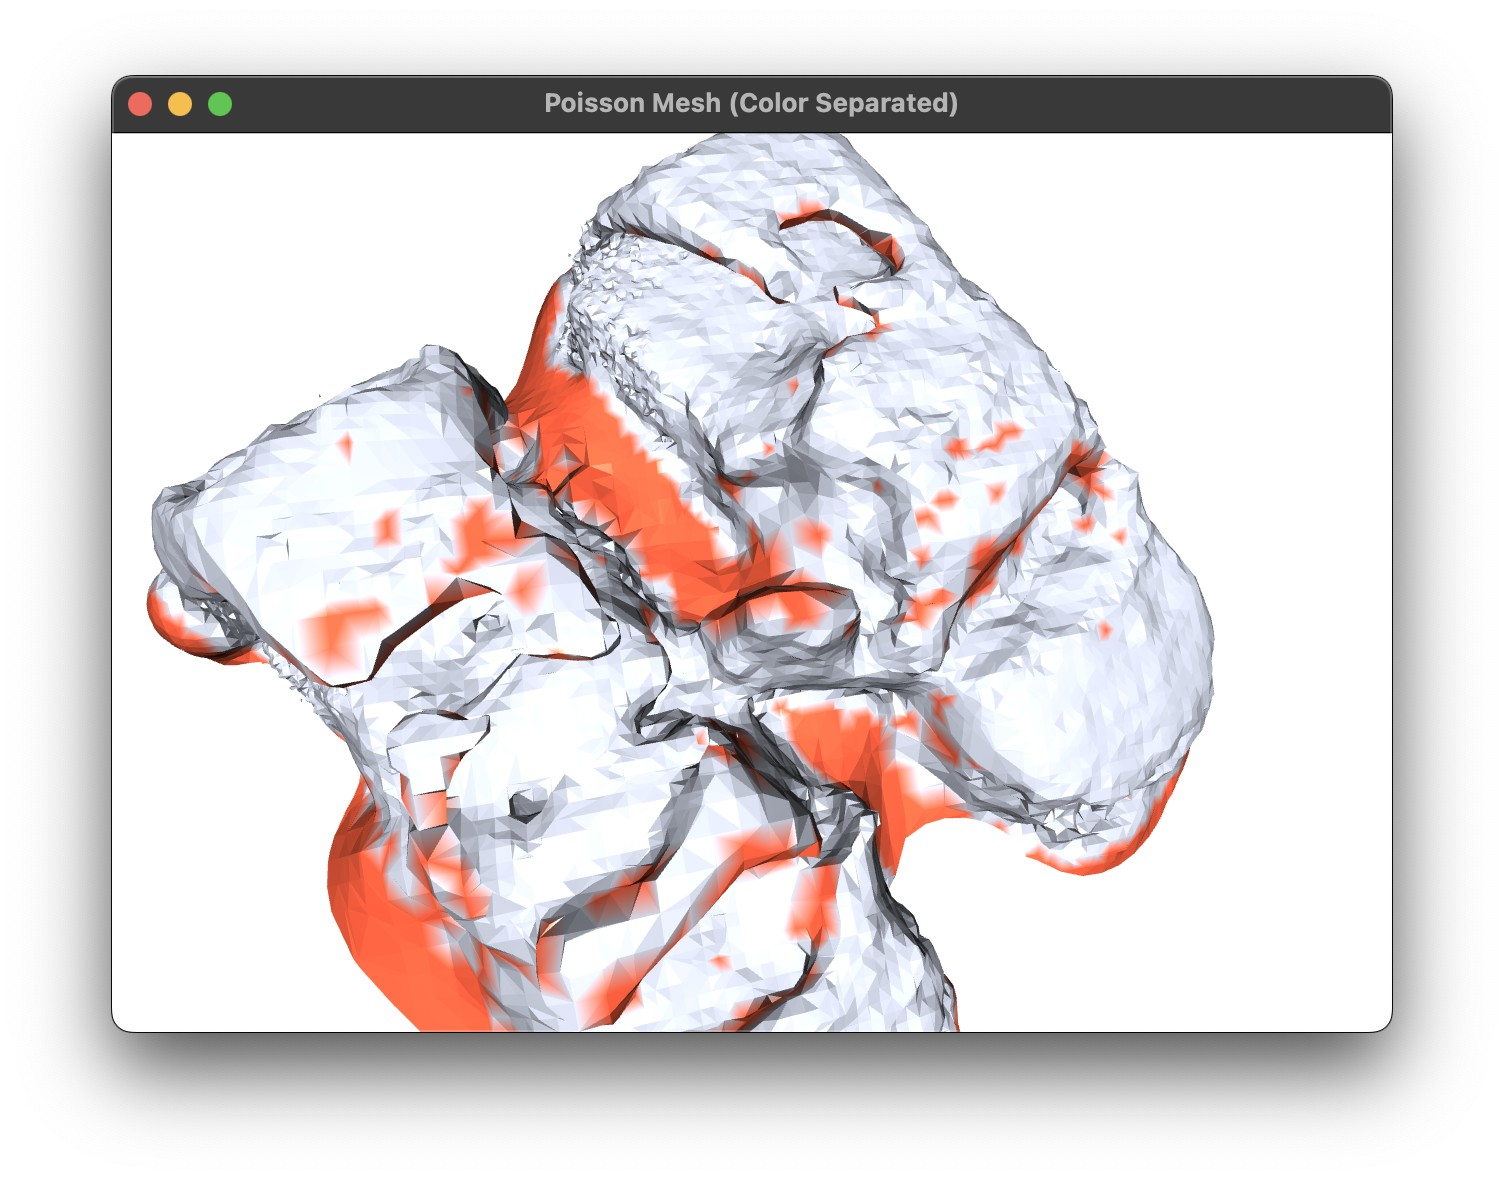